<a href="https://colab.research.google.com/github/saumyaranjansatpathy731-oss/unemployment_analysis/blob/main/UNEMPLOYMT_COVID_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**UNEMPLOYMENT IN COVID 19**

NAME: SAUMYA RANJAN SATAPATHY

BATCH: P1

OASIS INFOBYTE@DATASCIENCE INTERNSHIP


IMPORTING LIBRARIES

In [45]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

LOADING DATASET

In [46]:

df = pd.read_csv('Unemployment in India.csv')


df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


UNDERSTANDING DATASET

In [47]:

df.info()

df.describe()

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

CLEANING THE DATA

In [48]:

df.columns = df.columns.str.strip()

df.rename(columns={
    'Region': 'State',
    ' Date': 'Date',
    ' Frequency': 'Frequency',
    ' Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    ' Estimated Employed': 'Employed',
    ' Estimated Labour Participation Rate (%)': 'Labour_Rate'
}, inplace=True)

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df.isnull().sum()

df.dropna(inplace=True)

FEATURE ENGINEERING

In [49]:

df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

UNEMPLOMENT RATE DISTRIBUTION

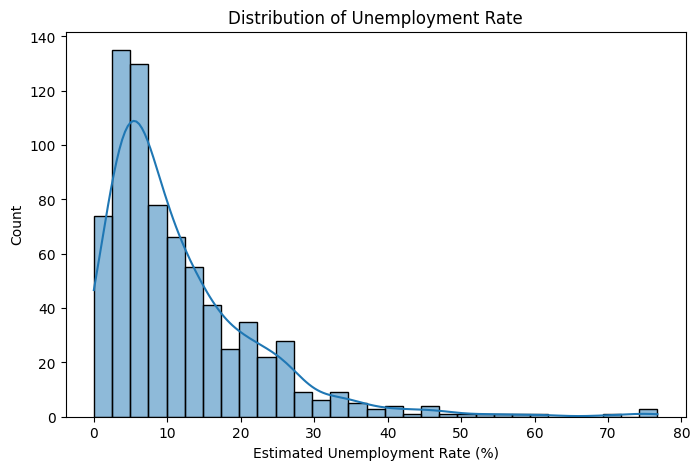

In [50]:
plt.figure(figsize=(8,5))
sns.histplot(df['Estimated Unemployment Rate (%)'], kde=True)
plt.title("Distribution of Unemployment Rate")
plt.show()

UNEMPLOYMENT BY STATES

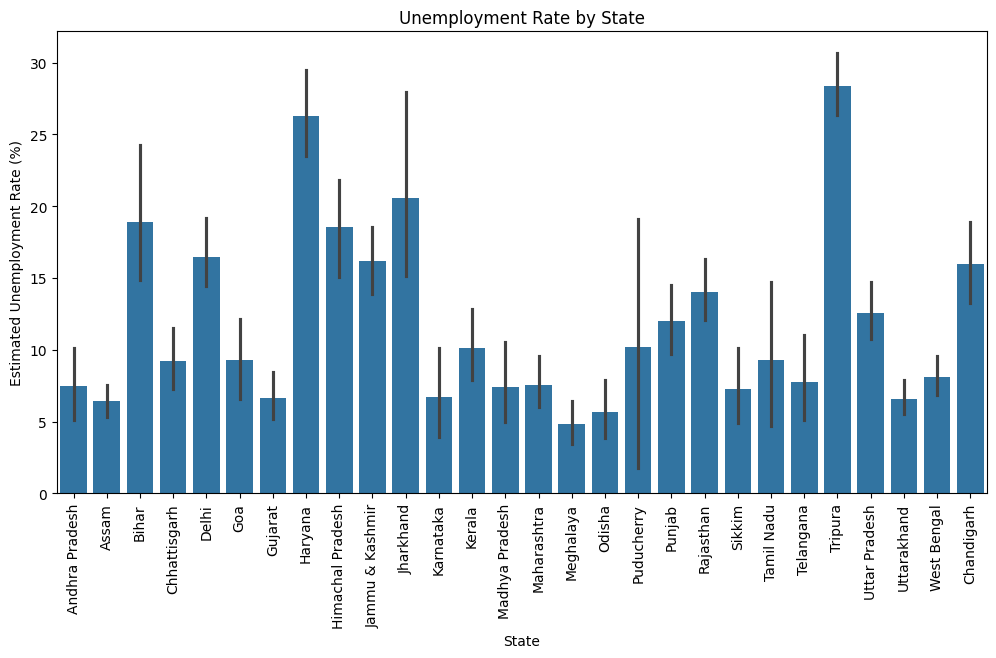

In [52]:
plt.figure(figsize=(12,6))
sns.barplot(x='State', y='Estimated Unemployment Rate (%)', data=df)
plt.xticks(rotation=90)
plt.title("Unemployment Rate by State")
plt.show()

MONTHLY TREND

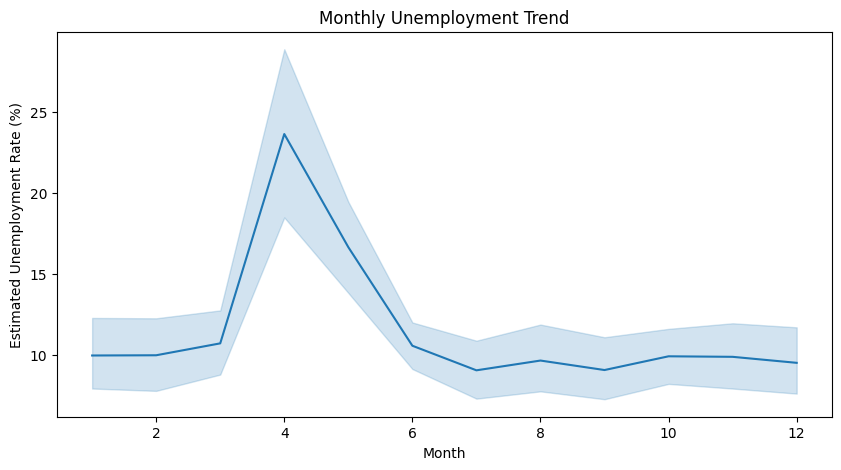

In [53]:
plt.figure(figsize=(10,5))
sns.lineplot(x='Month', y='Estimated Unemployment Rate (%)', data=df)
plt.title("Monthly Unemployment Trend")
plt.show()

COVID-19 IMPACT ANALYSIS

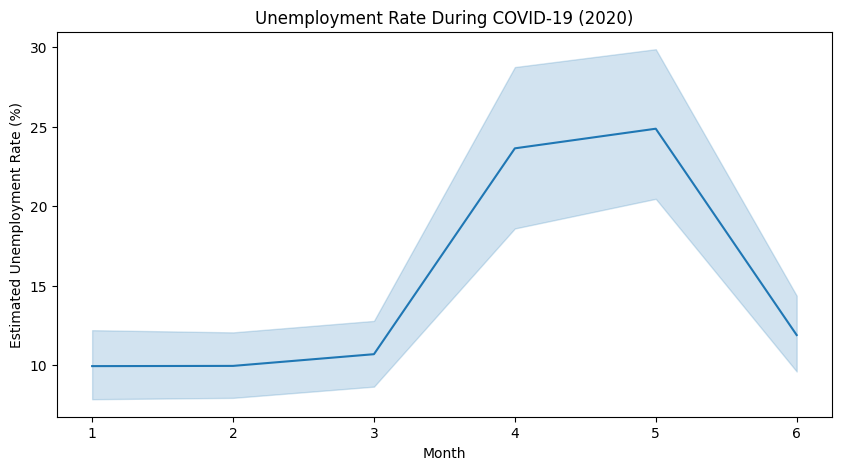

In [55]:

covid_df = df[df['Year'] == 2020]

plt.figure(figsize=(10,5))
sns.lineplot(x='Month', y='Estimated Unemployment Rate (%)', data=covid_df)
plt.title("Unemployment Rate During COVID-19 (2020)")
plt.show()

HEAT-MAP ANALYSIS



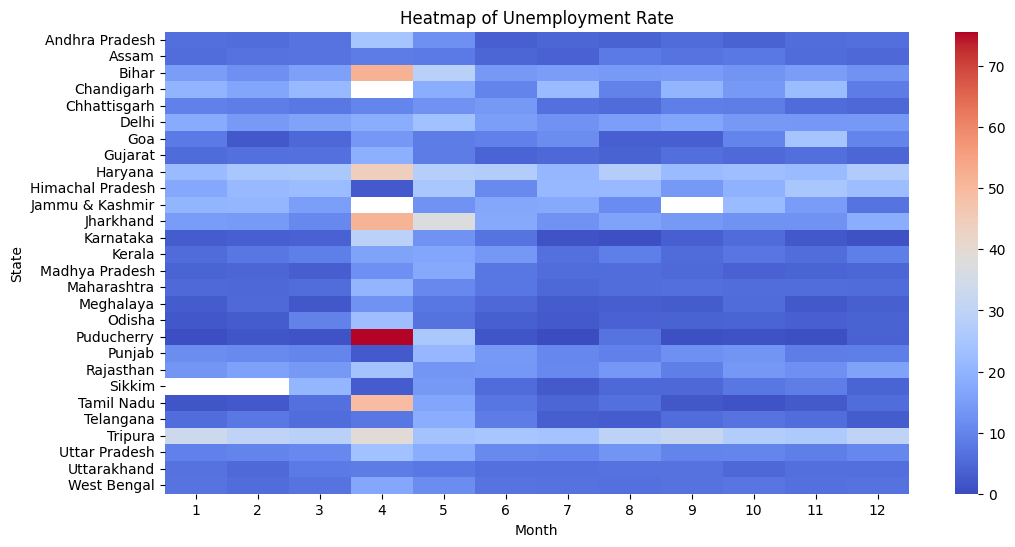

In [56]:
pivot = df.pivot_table(values='Estimated Unemployment Rate (%)',
                       index='State',
                       columns='Month')

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='coolwarm')
plt.title("Heatmap of Unemployment Rate")
plt.show()

TOP EFFECTED STATES

In [57]:
top_states = df.groupby('State')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

top_states.head(10)

,Estimated Unemployment Rate (%)
State,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features & target
X = df[['Month', 'Year']]
y = df['Estimated Unemployment Rate (%)']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
from sklearn.metrics import r2_score
print("Accuracy:", r2_score(y_test, y_pred))

Accuracy: 0.0902768678046122


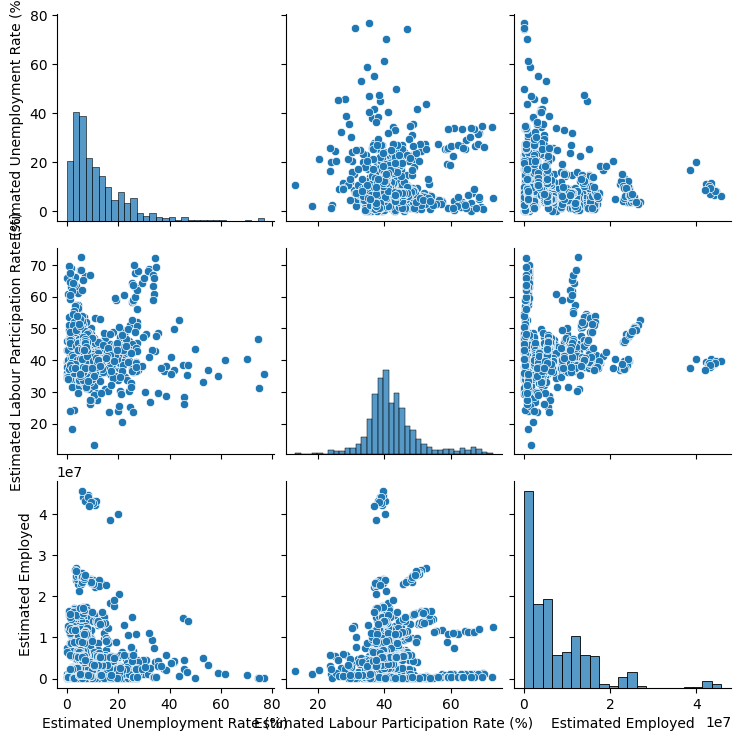

In [60]:
sns.pairplot(df[['Estimated Unemployment Rate (%)', 'Estimated Labour Participation Rate (%)', 'Estimated Employed']])
plt.show()